## 09 RA/OA ECM-Cell SpatioEv Module Paper Applications

**What this notebook does:** Demonstrates `spatioev.tl` ECM-cell API to analyze COL6 dark zones, cell-fiber distances, cross-Ripley's K, fiber Moran's I, and monocyte-CHP coupling in RA/OA synovial tissue.

**Data files needed:**
- Results from `08_RA_OA_ECM_cell_00_prepare_links.ipynb` (link tables)
- Results from `08_RA_OA_ECM_cell_05_chp_density_micro_holes_col6_dark_zone_segmentation.ipynb` (dark-zone labels)

**How to run:** Run the two prerequisite 08_ notebooks first. This notebook uses `spatioev.tl.ecm` (loaded via file path for optional-dependency isolation).

In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# Paper application analysis requires prior RA/OA results
_project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_results_dir = _project_root / "notebooks" / "results" / "ra_oa_ecm_cell"
_dark_dir = _results_dir / "chp_density_micro_holes_col6_dark_segmentation" / "outputs"
_required_files = [_results_dir, _dark_dir]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# Paper-guided ECM-cell spatial analysis with SpatioEv

This supplementary notebook demonstrates how the `spatioev.tl.ecm` module can be used to analyze ECM-cell spatial relationships in the RA/OA synovium dataset.

The analysis is organized around the main spatial biology from Richard et al., *Synovial matrix turnover controls immune cell spatial patterning in inflammation resolution* (PMC12583461):

- COL6A1-poor or COL6 dark zones contain immune-cell aggregates.
- Monocytes are comparatively able to enter COL6A1-rich tissue and are associated with collagen degradation.
- CHP marks active collagen degradation and can form ring-like or trajectory-like regions near COL6 dark-zone borders.
- COL6A1 deposition has a perivascular component near COL4A1-positive vasculature.
- ECM organization and ECM-cell coupling may differ between RA and OA.

The notebook assumes that the cell-fiber links and COL6 dark-zone labels have already been generated by:

`08_RA_OA_ECM_cell_00_prepare_links.ipynb` and `08_RA_OA_ECM_cell_05_chp_density_micro_holes_col6_dark_zone_segmentation.ipynb`.

**Interpretation guardrail.** Raw per-cell tables are saved for auditing and downstream analysis, but the manuscript-facing RA/OA plots should be interpreted at the image/sample level because the dataset contains 3 RA and 3 OA samples. Wherever possible, the displayed plots below aggregate each image first before comparing pathology groups.


In [2]:
%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spatioev as sv
from IPython.display import display
from scipy.stats import fisher_exact

# ── Nature/Cell publication rcParams ─────────────────────────────────────────
_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)

pd.set_option("display.max_columns", 180)

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR  = PROJECT_ROOT / "notebooks" / "results" / "ra_oa_ecm_cell"
DARK_DIR     = RESULTS_DIR / "chp_density_micro_holes_col6_dark_segmentation" / "outputs"
ANALYSIS_DIR = RESULTS_DIR / "spatioev_module_paper_applications"
FIGURES_DIR  = ANALYSIS_DIR / "figures"
TABLES_DIR   = ANALYSIS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ── sv.tl ECM-cell API imports ────────────────────────────────────────────────
# [reason] All ECM-cell functions have migrated from ecm.py /
# spatial_ecm_links.py into spatioev.tl.ecm — accessible via sv.tl directly.
from spatioev.tl import (
    build_ecm_cell_neighborhood_features,
    cluster_ecm_cell_neighborhoods,
    score_col6_dark_neighborhoods,
    spatial_enrichment_score,
    filter_ecm_cell_inputs_by_tissue,
    build_cell_fiber_links,
    build_nearest_cell_fiber_map,
    cell_to_fiber_distance,
    fiber_density_near_cells,
    cross_ripleys_k,
    morans_i_fibers,
    local_morans_i_fibers,
    cross_morans_i_ecm_cells,
    cross_morans_i_ecm_cells_permutation_test,
    map_cells_to_fibers,
    map_cells_to_fibers_kernel,
    local_cross_morans_i_ecm_cells,
)

# cross_ripleys_k_permutation_envelope lives in spatioev.tl.ecm directly
from spatioev.tl.ecm import cross_ripleys_k_permutation_envelope

print("Project root:", PROJECT_ROOT)
print("sv version:", sv.__version__)
print("ECM functions imported from sv.tl ✓")


Project root: /Users/shihongwu/SpatioEv
sv version: 0.1.0
ECM functions imported from sv.tl ✓


## Parameters

Spatial coordinates in this dataset are in pixels. Distances are converted to microns for plotting using `PIXEL_SIZE_UM`.

For manuscript-quality permutation tests, increase `N_RIPLEY_SIM` and `N_CROSS_MORAN_SIM`. The defaults below are intentionally modest so the notebook can run interactively.


In [3]:
PIXEL_SIZE_UM = 0.325
IMAGE_KEY = "imageid"
GROUP_KEY = "pathology"
PHENOTYPE_KEY = "phenotype"
FIBER_TYPE_KEY = "fiber_type"
X_KEY = "X_centroid"
Y_KEY = "Y_centroid"

PAPER_CELL_TYPES = [
    "B cells",
    "CD4 T cells",
    "CD8 T cells",
    "T cells",
    "Dendritic cells",
    "Macrophages",
    "MERTK+ Macrophages",
    "Monocytes",
    "Neutrophils",
    "Vascular cells",
]

PAPER_FIBER_TYPES = ["COL6A1", "CHP", "COL4A1", "FN", "COL1A1bis"]
MORAN_FEATURES = ["area", "major_axis_length", "eccentricity", "alignment_score"]

# Radius values for cell-fiber analyses. Coordinates are in pixels, so um values are converted below.
PROXIMITY_RADIUS_UM = 50
PROXIMITY_RADIUS_PX = PROXIMITY_RADIUS_UM / PIXEL_SIZE_UM
RIPLEY_RADII_UM = np.array([10, 20, 30, 40, 50], dtype=float)
RIPLEY_RADII_PX = RIPLEY_RADII_UM / PIXEL_SIZE_UM

# Computational controls. Keep permutations off during exploratory runs; switch on for finalized claims.
RUN_RIPLEY_PERMUTATIONS = False
RUN_CROSS_MORAN_PERMUTATIONS = False
N_RIPLEY_SIM = 49
N_CROSS_MORAN_SIM = 99
MAX_FIBERS_FOR_MORAN = 2500
MAX_FIBERS_FOR_LOCAL_PLOTS = 5000
RANDOM_STATE = 0

# Representative image used for spatial QC panels. If unavailable, the notebook falls back to the first image.
QC_IMAGE = "JRP112"

print("Radii, um:", RIPLEY_RADII_UM)
print("Radii, px:", np.round(RIPLEY_RADII_PX, 1))


Radii, um: [10. 20. 30. 40. 50.]
Radii, px: [ 30.8  61.5  92.3 123.1 153.8]


## Load cells, fibers, links, and COL6 dark-zone labels

`adata` contains cell phenotypes and coordinates. `fiber_df` contains segmented ECM fibers. `links_df` contains precomputed cell-fiber links and distances. The dark-zone assignments were generated in the previous COL6 dark-zone segmentation notebook.


In [4]:
# [reason] sv.load_h5ad handles format/version checks and backed reads
adata = sv.load_h5ad(PROJECT_ROOT / "data" / "RA_OA" / "tmp6.h5ad")
fiber_df = pd.read_pickle(RESULTS_DIR / "ra_oa_fiber_df.pkl")
links_df = pd.read_pickle(RESULTS_DIR / "ra_oa_cell_fiber_links.pkl")
sample_metadata = pd.read_csv(RESULTS_DIR / "ra_oa_sample_metadata.csv")

cell_dark = pd.read_csv(DARK_DIR / "04_cell_chp_micro_hole_region_assignments.csv")
image_region_metrics = pd.read_csv(DARK_DIR / "03_chp_micro_hole_image_region_edge_metrics.csv")
cell_region_counts = pd.read_csv(DARK_DIR / "06_cell_region_phenotype_counts.csv")

# Add COL6 dark-zone calls back to adata.obs using cell IDs.
adata.obs["cell_id"] = adata.obs.index.astype(str)
dark_cols = ["cell_id", "COL6_dark_region", "dark_component", "COL6_dark_score", "CHP_density_rank"]
dark_lookup = cell_dark[dark_cols].drop_duplicates("cell_id").set_index("cell_id")
for col in dark_cols[1:]:
    adata.obs[col] = adata.obs["cell_id"].map(dark_lookup[col])

adata.obs["COL6_dark_region"] = adata.obs["COL6_dark_region"].fillna("outside_tissue")
adata.obs["in_COL6_dark_core"] = adata.obs["COL6_dark_region"].eq("core").astype(float)
adata.obs["in_COL6_dark_or_edge"] = adata.obs["COL6_dark_region"].isin(["core", "inner_edge", "outer_edge"]).astype(float)

for phenotype in adata.obs[PHENOTYPE_KEY].dropna().unique():
    safe_name = phenotype.replace(" ", "_").replace("+", "pos").replace("/", "_")
    adata.obs[f"is_{safe_name}"] = adata.obs[PHENOTYPE_KEY].eq(phenotype).astype(float)

print("Cells:", adata.shape)
print("Fibers:", fiber_df.shape)
print("Links:", links_df.shape)
print("Images:", sorted(adata.obs[IMAGE_KEY].unique()))
print("Cell phenotypes:", sorted(adata.obs[PHENOTYPE_KEY].dropna().unique()))
print("Fiber types:", sorted(fiber_df[FIBER_TYPE_KEY].dropna().unique()))


Cells: (662388, 28)
Fibers: (548442, 14)
Links: (22495433, 4)
Images: ['JRP112', 'JRP122', 'JRP141', 'JRP144', 'S00292623', 'S00293087']
Cell phenotypes: ['B cells', 'CD4 T cells', 'CD8 T cells', 'Dendritic cells', 'MERTK+ Macrophages', 'Macrophages', 'Monocytes', 'Myeloid cells', 'Neutrophils', 'Non-immune cells', 'Other Immune cells', 'Plasma cells', 'T cells', 'Vascular cells']
Fiber types: ['CHP', 'COL1A1bis', 'COL4A1', 'COL6A1', 'FN', 'MFAP5']


In [5]:
def savefig(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=250, bbox_inches="tight")
    print("Saved:", path)


def sample_fibers(df, max_n=MAX_FIBERS_FOR_MORAN, random_state=RANDOM_STATE):
    if len(df) <= max_n:
        return df.copy()
    return df.sample(max_n, random_state=random_state).copy()


def subset_image_objects(image_id):
    adata_img = adata[adata.obs[IMAGE_KEY].eq(image_id)].copy()
    fiber_img = fiber_df[fiber_df[IMAGE_KEY].eq(image_id)].copy()
    links_img = links_df[links_df[IMAGE_KEY].eq(image_id)].copy()
    return adata_img, fiber_img, links_img


def safe_phenotypes(types):
    available = set(adata.obs[PHENOTYPE_KEY].dropna().unique())
    return [x for x in types if x in available]


def safe_fiber_types(types):
    available = set(fiber_df[FIBER_TYPE_KEY].dropna().unique())
    return [x for x in types if x in available]


def choose_qc_image(preferred):
    images = sorted(adata.obs[IMAGE_KEY].dropna().unique())
    return preferred if preferred in images else images[0]


def sample_level_summary(df, group_cols, value_col, summary_name="median_value"):
    """Aggregate per-cell rows to one row per image-level comparison unit."""
    return (
        df.groupby(group_cols, observed=True)
        .agg(
            **{
                summary_name: (value_col, "median"),
                f"mean_{value_col}": (value_col, "mean"),
                "n_observations": (value_col, "size"),
            }
        )
        .reset_index()
    )

paper_cell_types = safe_phenotypes(PAPER_CELL_TYPES)
paper_fiber_types = safe_fiber_types(PAPER_FIBER_TYPES)
qc_image = choose_qc_image(QC_IMAGE)
print("Using cell types:", paper_cell_types)
print("Using fiber types:", paper_fiber_types)
print("QC image:", qc_image)


Using cell types: ['B cells', 'CD4 T cells', 'CD8 T cells', 'T cells', 'Dendritic cells', 'Macrophages', 'MERTK+ Macrophages', 'Monocytes', 'Neutrophils', 'Vascular cells']
Using fiber types: ['COL6A1', 'CHP', 'COL4A1', 'FN', 'COL1A1bis']
QC image: JRP112


# ── COL6 dark zones: cell localisation and area-normalised density ───────────
# [reason] RA synovial tissue contains COL6-dense "dark zones" enriched for
# specific immune cell subsets. This section quantifies per-region cell density.
## 1. COL6 dark zones: cell localization and area-normalized density

Paper-guided question: are immune cell subsets enriched in COL6 dark-zone core/edge regions compared with background tissue?

This first block uses the dark-zone labels from the segmentation notebook. It is not yet using the ECM-cell module; it provides biological context for the module demonstrations that follow.


### Spatial QC: COL6 dark-zone calls with COL6A1 and CHP fibers

This panel is not a statistical result; it is a sanity check. It helps confirm that the dark-zone labels occupy plausible tissue regions and that COL6A1/CHP fiber distributions visually match the biology before we quantify cell localization.


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/00_spatial_qc_col6_dark_zone_ecm_overlay.png


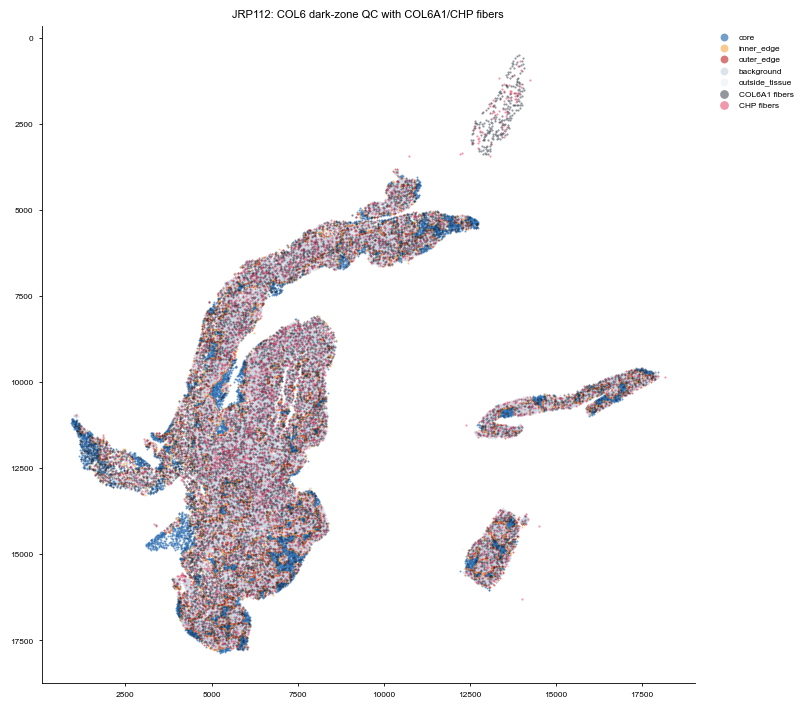

In [6]:
region_order = ["core", "inner_edge", "outer_edge", "background", "outside_tissue"]
region_palette = {
    "core": "#2b6cb0",
    "inner_edge": "#f6ad55",
    "outer_edge": "#c53030",
    "background": "#cbd5e0",
    "outside_tissue": "#edf2f7",
}

cell_qc = cell_dark[cell_dark[IMAGE_KEY].eq(qc_image)].copy()
fiber_qc = fiber_df[fiber_df[IMAGE_KEY].eq(qc_image)].copy()

fig, ax = plt.subplots(figsize=(8, 8))
for region in region_order:
    sub = cell_qc[cell_qc["COL6_dark_region"].eq(region)]
    if sub.empty:
        continue
    ax.scatter(
        sub[X_KEY],
        sub[Y_KEY],
        s=2,
        color=region_palette.get(region, "lightgray"),
        alpha=0.65,
        linewidth=0,
        label=region,
        rasterized=True,
    )

for fiber_type, color, marker_size in [("COL6A1", "#111827", 2.5), ("CHP", "#e11d48", 2.5)]:
    sub = fiber_qc[fiber_qc[FIBER_TYPE_KEY].eq(fiber_type)]
    if sub.empty:
        continue
    sub = sample_fibers(sub, max_n=12000)
    ax.scatter(
        sub[X_KEY],
        sub[Y_KEY],
        s=marker_size,
        color=color,
        alpha=0.45,
        linewidth=0,
        label=f"{fiber_type} fibers",
        rasterized=True,
    )

ax.set_title(f"{qc_image}: COL6 dark-zone QC with COL6A1/CHP fibers")
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.grid(False)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, markerscale=4)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "00_spatial_qc_col6_dark_zone_ecm_overlay.png")
plt.show()


,imageid,pathology,phenotype,COL6_dark_region,n_cells,fraction_of_phenotype
0,JRP112,RA,B cells,background,321,0.746512
1,JRP112,RA,B cells,core,51,0.118605
2,JRP112,RA,B cells,inner_edge,26,0.060465
3,JRP112,RA,B cells,outer_edge,32,0.074419
4,JRP112,RA,CD4 T cells,background,7271,0.617967


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/01_col6_dark_region_cell_fraction_by_phenotype.png


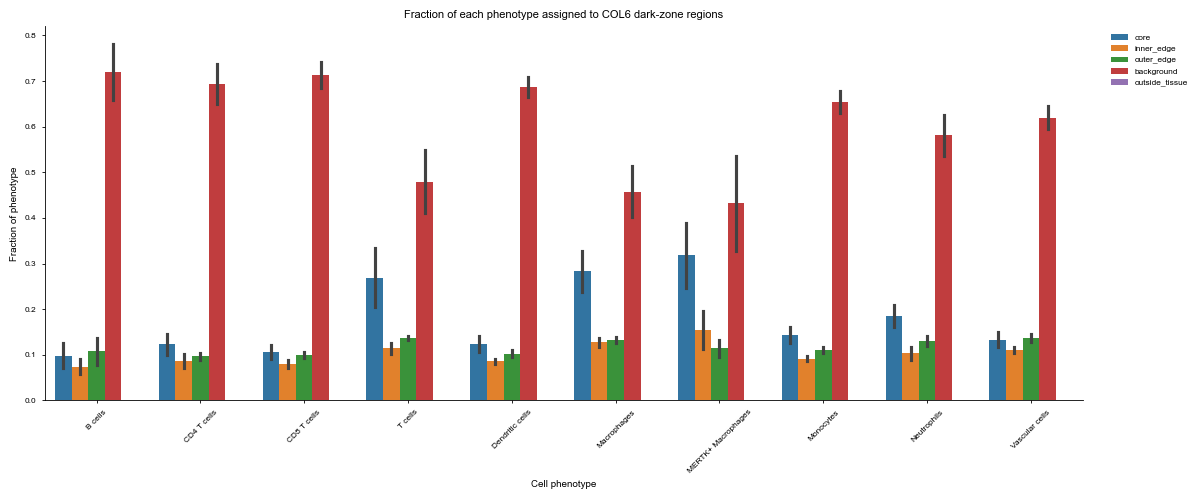

In [7]:
region_order = ["core", "inner_edge", "outer_edge", "background", "outside_tissue"]
plot_counts = cell_region_counts[cell_region_counts[PHENOTYPE_KEY].isin(paper_cell_types)].copy()
plot_counts["COL6_dark_region"] = pd.Categorical(
    plot_counts["COL6_dark_region"],
    categories=region_order,
    ordered=True,
)
plot_counts.to_csv(TABLES_DIR / "01_col6_dark_region_cell_fraction_by_phenotype.csv", index=False)
display(plot_counts.head())

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_counts[plot_counts["COL6_dark_region"].isin(["core", "inner_edge", "outer_edge", "background"])],
    x=PHENOTYPE_KEY,
    y="fraction_of_phenotype",
    hue="COL6_dark_region",
    order=paper_cell_types,
    errorbar="se",
    ax=ax,
)
ax.set_title("Fraction of each phenotype assigned to COL6 dark-zone regions")
ax.set_xlabel("Cell phenotype")
ax.set_ylabel("Fraction of phenotype")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "01_col6_dark_region_cell_fraction_by_phenotype.png")
plt.show()


,imageid,pathology,phenotype,COL6_dark_region,n_cells,area_mm2,cell_density_per_mm2
0,JRP112,RA,B cells,background,321,3.378080,95.024393
1,JRP112,RA,B cells,core,51,1.262032,40.411020
2,JRP112,RA,B cells,inner_edge,26,0.753584,34.501794
3,JRP112,RA,B cells,outer_edge,32,0.720448,44.416807
4,JRP112,RA,CD4 T cells,background,7271,3.378080,2152.406101


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/02_col6_dark_region_cell_density_per_area.png


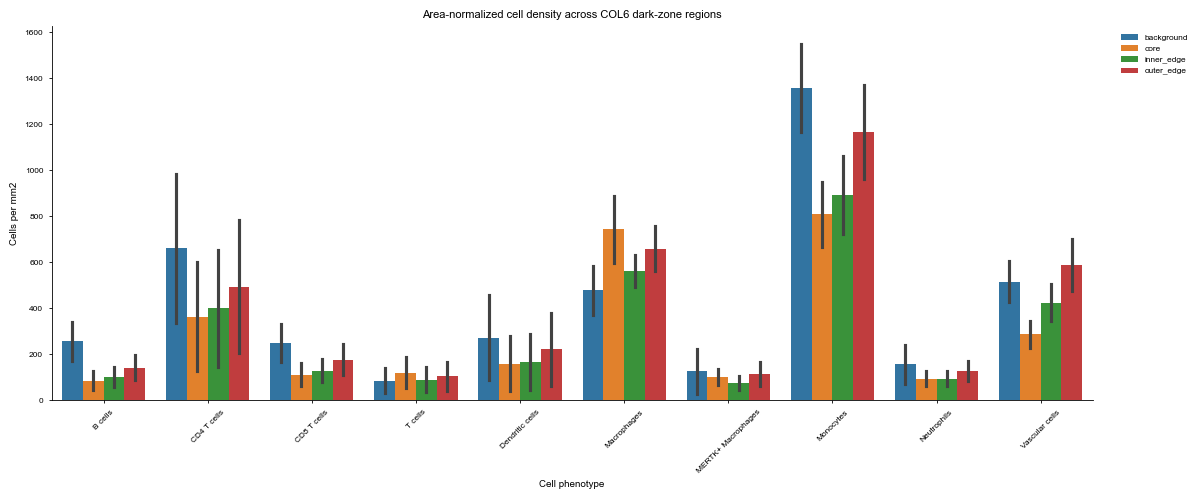

In [8]:
# Area-normalized density avoids confusing region size with cellular enrichment.
area_df = (
    image_region_metrics[image_region_metrics["dark_component"].astype(str).eq("all")]
    [[IMAGE_KEY, GROUP_KEY, "region", "area_mm2"]]
    .rename(columns={"region": "COL6_dark_region"})
)

cell_density_region = (
    cell_dark[cell_dark[PHENOTYPE_KEY].isin(paper_cell_types)]
    .groupby([IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region"], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(area_df, on=[IMAGE_KEY, GROUP_KEY, "COL6_dark_region"], how="left")
)
cell_density_region["cell_density_per_mm2"] = cell_density_region["n_cells"] / cell_density_region["area_mm2"]
cell_density_region.to_csv(TABLES_DIR / "02_col6_dark_region_cell_density_per_area.csv", index=False)
display(cell_density_region.head())

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=cell_density_region[cell_density_region["COL6_dark_region"].isin(["core", "inner_edge", "outer_edge", "background"])],
    x=PHENOTYPE_KEY,
    y="cell_density_per_mm2",
    hue="COL6_dark_region",
    order=paper_cell_types,
    errorbar="se",
    ax=ax,
)
ax.set_title("Area-normalized cell density across COL6 dark-zone regions")
ax.set_xlabel("Cell phenotype")
ax.set_ylabel("Cells per mm2")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "02_col6_dark_region_cell_density_per_area.png")
plt.show()


**How to read this section.** The fraction plot asks, “where do cells of this phenotype fall?” but it is sensitive to region size. The area-normalized density plot is the better biological readout for immune enrichment or depletion, because a large background compartment will naturally contain more cells even without enrichment.


# ── Cell-to-fiber nearest distance ──────────────────────────────────────────
# [reason] sv.tl.cell_to_fiber_distance computes per-cell nearest linked fiber
# distance, revealing how close different immune cells sit to the ECM network.
## 2. Nearest cell-to-fiber distance

SpatioEv function showcased: `cell_to_fiber_distance`.

Paper-guided questions:

- Are lymphocytes and macrophages farther from COL6A1 fibers than monocytes?
- Are monocytes closer to CHP fibers, consistent with degradation-associated migration?
- Are vascular cells close to COL4A1 fibers as a positive control?


,imageid,pathology,phenotype,fiber_type,median_distance_um,mean_distance_um,n_observations
0,JRP112,RA,B cells,CHP,15.816714,18.260132,403
1,JRP112,RA,B cells,COL4A1,26.992696,27.674587,334
2,JRP112,RA,B cells,COL6A1,10.361262,11.524294,430
3,JRP112,RA,B cells,FN,9.894939,10.296696,430
4,JRP112,RA,CD4 T cells,CHP,20.290368,22.124294,10891


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/03_nearest_cell_to_fiber_distance_by_phenotype.png


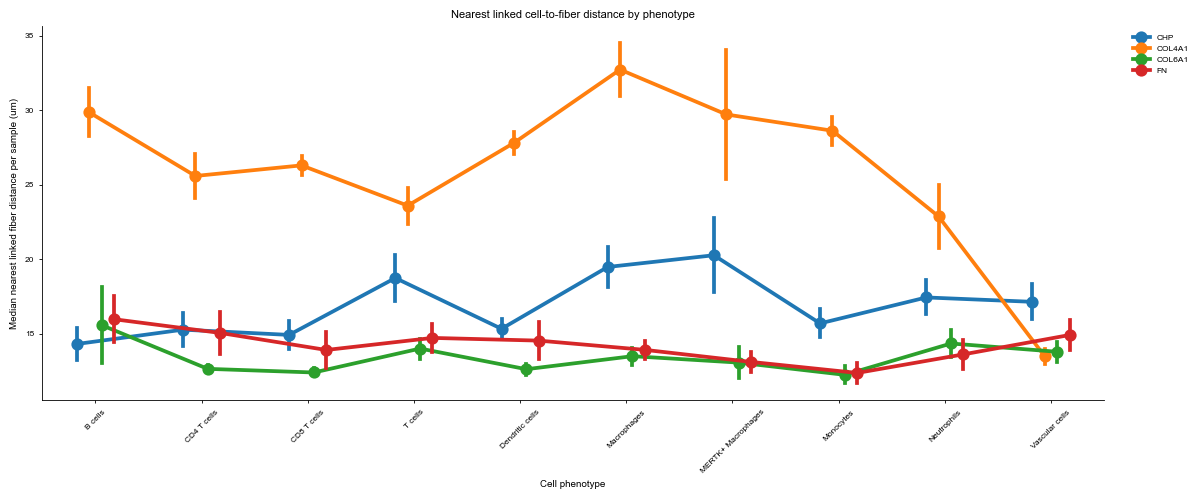

In [9]:
adata_distance = adata.copy()
for fiber_type in ["COL6A1", "CHP", "COL4A1", "FN"]:
    if fiber_type not in set(fiber_df[FIBER_TYPE_KEY]):
        continue
    adata_distance = cell_to_fiber_distance(
        adata_distance,
        fiber_df,
        links_df,
        fiber_type_key=FIBER_TYPE_KEY,
        fiber_type=fiber_type,
        phenotype_key=PHENOTYPE_KEY,
        phenotype=paper_cell_types,
    )

distance_cols = [c for c in adata_distance.obs.columns if c.startswith("dist_to_")]
distance_df = adata_distance.obs[[IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region"] + distance_cols].copy()
distance_long = distance_df.melt(
    id_vars=[IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region"],
    value_vars=distance_cols,
    var_name="fiber_distance",
    value_name="distance_px",
).dropna(subset=["distance_px"])
distance_long["fiber_type"] = distance_long["fiber_distance"].str.replace("dist_to_", "", regex=False)
distance_long["distance_um"] = distance_long["distance_px"] * PIXEL_SIZE_UM
distance_long.to_csv(TABLES_DIR / "03_cell_to_fiber_nearest_distance_long.csv", index=False)

# Plot image-level medians rather than individual cells to avoid pseudo-replication.
distance_sample = sample_level_summary(
    distance_long[distance_long[PHENOTYPE_KEY].isin(paper_cell_types)],
    [IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "fiber_type"],
    "distance_um",
    summary_name="median_distance_um",
)
distance_sample.to_csv(TABLES_DIR / "03b_cell_to_fiber_nearest_distance_by_sample.csv", index=False)
display(distance_sample.head())

fig, ax = plt.subplots(figsize=(12, 5))
sns.pointplot(
    data=distance_sample,
    x=PHENOTYPE_KEY,
    y="median_distance_um",
    hue="fiber_type",
    order=paper_cell_types,
    errorbar="se",
    dodge=0.35,
    ax=ax,
)
ax.set_title("Nearest linked cell-to-fiber distance by phenotype")
ax.set_xlabel("Cell phenotype")
ax.set_ylabel("Median nearest linked fiber distance per sample (um)")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "03_nearest_cell_to_fiber_distance_by_phenotype.png")
plt.show()


**How to read this section.** `cell_to_fiber_distance` reports the nearest **linked** fiber distance, so it is conditional on the link table radius used during data preparation. A short distance supports local proximity; a long or missing distance can reflect either biological separation or absence of a linked fiber within the search radius. The displayed plot uses one median per image/sample/phenotype/fiber type.


## 3. Fiber density near cells

SpatioEv function showcased: `fiber_density_near_cells`.

Paper-guided questions:

- Do immune cells in COL6 dark zones experience lower local COL6A1 density?
- Do monocytes experience higher CHP or COL6A1 density than lymphocytes?
- Does the local ECM context differ between RA and OA?


,imageid,pathology,phenotype,COL6_dark_region,fiber_type,density_per_mm2
0,JRP112,RA,B cells,background,CHP,763.943727
1,JRP112,RA,B cells,background,COL4A1,254.647909
2,JRP112,RA,B cells,background,COL6A1,1527.887454
3,JRP112,RA,B cells,background,FN,1782.535363
4,JRP112,RA,B cells,core,CHP,254.647909


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/04_fiber_density_near_cells_col6_chp.png


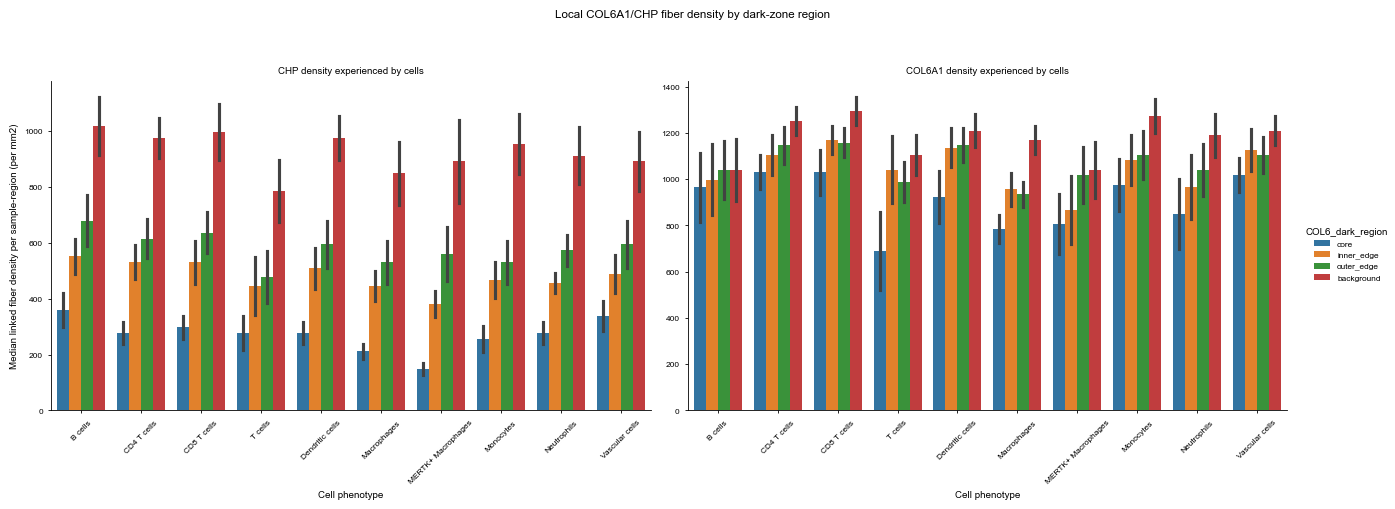

In [10]:
# ── Fiber density near cells ────────────────────────────────────────────────
# [reason] sv.tl.fiber_density_near_cells reports how dense the local ECM
# environment is around each cell — complements distance with density context.
adata_density = adata.copy()
for fiber_type in ["COL6A1", "CHP", "COL4A1", "FN"]:
    if fiber_type not in set(fiber_df[FIBER_TYPE_KEY]):
        continue
    adata_density = fiber_density_near_cells(
        adata_density,
        fiber_df,
        links_df,
        fiber_type_key=FIBER_TYPE_KEY,
        fiber_type=fiber_type,
        phenotype_key=PHENOTYPE_KEY,
        phenotype=paper_cell_types,
        normalize=True,
        density_radius=PROXIMITY_RADIUS_PX,
    )

density_cols = [c for c in adata_density.obs.columns if c.endswith("_density") and c.split("_density")[0] in PAPER_FIBER_TYPES]
density_df = adata_density.obs[[IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region"] + density_cols].copy()
density_long = density_df.melt(
    id_vars=[IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region"],
    value_vars=density_cols,
    var_name="fiber_type",
    value_name="density_per_px2",
).dropna(subset=["density_per_px2"])
density_long["fiber_type"] = density_long["fiber_type"].str.replace("_density", "", regex=False)
density_long["density_per_mm2"] = density_long["density_per_px2"] / (PIXEL_SIZE_UM ** 2) * 1e6

density_summary = (
    density_long
    .groupby([IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "COL6_dark_region", "fiber_type"], observed=True)
    ["density_per_mm2"]
    .median()
    .reset_index()
)
density_summary.to_csv(TABLES_DIR / "04_fiber_density_near_cells_by_region.csv", index=False)
display(density_summary.head())

plot_df = density_summary[
    density_summary[PHENOTYPE_KEY].isin(paper_cell_types)
    & density_summary["fiber_type"].isin(["COL6A1", "CHP"])
    & density_summary["COL6_dark_region"].isin(["core", "inner_edge", "outer_edge", "background"])
].copy()
plot_df["COL6_dark_region"] = pd.Categorical(
    plot_df["COL6_dark_region"],
    categories=["core", "inner_edge", "outer_edge", "background"],
    ordered=True,
)

g = sns.catplot(
    data=plot_df,
    kind="bar",
    x=PHENOTYPE_KEY,
    y="density_per_mm2",
    hue="COL6_dark_region",
    col="fiber_type",
    order=paper_cell_types,
    errorbar="se",
    height=4.5,
    aspect=1.45,
    sharey=False,
)
g.set_axis_labels("Cell phenotype", "Median linked fiber density per sample-region (per mm2)")
g.set_titles("{col_name} density experienced by cells")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    sns.despine(ax=ax)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Local COL6A1/CHP fiber density by dark-zone region")
savefig(g.fig, "04_fiber_density_near_cells_col6_chp.png")
plt.show()


**How to read this section.** `fiber_density_near_cells` asks what ECM environment each cell experiences locally. Here we keep the COL6 dark-zone region in the plot, because the same phenotype can experience very different COL6A1/CHP neighborhoods in core, edge, and background compartments.


## 4. Cross Ripley's K: cell-fiber association across spatial scales

SpatioEv functions showcased: `cross_ripleys_k` and optionally `cross_ripleys_k_permutation_envelope`.

Paper-guided pairs:

- lymphocytes versus COL6A1, for immune exclusion or confinement;
- monocytes versus COL6A1 and CHP, for degradation-associated migration;
- vascular cells versus COL4A1, as a positive-control vascular association;
- MERTK+ macrophages and T cells versus COL6A1/COL4A1, for perivascular COL6 biology.

`L_minus_r > 0` indicates attraction/association at that radius; `L_minus_r < 0` indicates separation/exclusion.


In [11]:
# ── Cross Ripley's K: cell-fiber spatial association ────────────────────────
# [reason] sv.tl.cross_ripleys_k tests whether cell-fiber co-localisation
# exceeds what is expected by chance across a range of spatial radii.
ripley_pairs = [
    ("COL6A1", "B cells", "B cells vs COL6A1"),
    ("COL6A1", "CD4 T cells", "CD4 T cells vs COL6A1"),
    ("COL6A1", "CD8 T cells", "CD8 T cells vs COL6A1"),
    ("COL6A1", "Monocytes", "Monocytes vs COL6A1"),
    ("CHP", "Monocytes", "Monocytes vs CHP"),
    ("COL4A1", "Vascular cells", "Vascular cells vs COL4A1"),
    ("COL6A1", "MERTK+ Macrophages", "MERTK+ macrophages vs COL6A1"),
    ("COL6A1", "T cells", "T cells vs COL6A1"),
]
ripley_pairs = [(f, p, label) for f, p, label in ripley_pairs if f in paper_fiber_types and p in paper_cell_types]

ripley_rows = []
for image_id in sorted(adata.obs[IMAGE_KEY].unique()):
    adata_img, fiber_img, links_img = subset_image_objects(image_id)
    pathology = adata_img.obs[GROUP_KEY].dropna().iloc[0]
    for fiber_type, phenotype, label in ripley_pairs:
        n_cells = int(adata_img.obs[PHENOTYPE_KEY].eq(phenotype).sum())
        n_fibers = int(fiber_img[FIBER_TYPE_KEY].eq(fiber_type).sum())
        if n_cells < 10 or n_fibers < 10:
            continue
        try:
            curve = cross_ripleys_k(
                adata_img,
                fiber_img,
                links_img,
                RIPLEY_RADII_PX,
                fiber_type_key=FIBER_TYPE_KEY,
                fiber_type=fiber_type,
                phenotype_key=PHENOTYPE_KEY,
                phenotype=phenotype,
                check_radius=False,
            )
        except Exception as exc:
            warnings.warn(f"Skipping {image_id} {label}: {exc}")
            continue
        if curve.empty:
            continue
        curve[IMAGE_KEY] = image_id
        curve[GROUP_KEY] = pathology
        curve["fiber_type"] = fiber_type
        curve[PHENOTYPE_KEY] = phenotype
        curve["comparison"] = label
        curve["radius_um"] = curve["radius"] * PIXEL_SIZE_UM
        ripley_rows.append(curve)

ripley_df = pd.concat(ripley_rows, ignore_index=True) if ripley_rows else pd.DataFrame()
ripley_df.to_csv(TABLES_DIR / "05_cross_ripleys_k_cell_fiber_curves.csv", index=False)
display(ripley_df.head())

if not ripley_df.empty:
    ripley_key = ripley_df[ripley_df["radius_um"].round(1).isin([30.0, 50.0])].copy()
    ripley_key.to_csv(TABLES_DIR / "05b_cross_ripleys_key_radius_values.csv", index=False)

    g = sns.relplot(
        data=ripley_df,
        x="radius_um",
        y="L_minus_r",
        hue=GROUP_KEY,
        col="comparison",
        col_wrap=4,
        kind="line",
        estimator="mean",
        errorbar="se",
        height=3.0,
        aspect=1.1,
        facet_kws={"sharey": False},
    )
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Radius (um)")
        ax.set_ylabel("L(r) - r")
        sns.despine(ax=ax)
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Cross Ripley's K cell-fiber association curves")
    savefig(g.fig, "05_cross_ripleys_k_cell_fiber_curves.png")
    plt.show()


/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_4224/3032239881.py:38: UserWarning: Skipping JRP112 B cells vs COL6A1: cross_ripleys_k() got an unexpected keyword argument 'fiber_type_key'
  warnings.warn(f"Skipping {image_id} {label}: {exc}")
/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_4224/3032239881.py:38: UserWarning: Skipping JRP112 CD4 T cells vs COL6A1: cross_ripleys_k() got an unexpected keyword argument 'fiber_type_key'
  warnings.warn(f"Skipping {image_id} {label}: {exc}")
/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_4224/3032239881.py:38: UserWarning: Skipping JRP112 CD8 T cells vs COL6A1: cross_ripleys_k() got an unexpected keyword argument 'fiber_type_key'
  warnings.warn(f"Skipping {image_id} {label}: {exc}")
/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_4224/3032239881.py:38: UserWarning: Skipping JRP112 Monocytes vs COL6A1: cross_ripleys_k() got an unexpected keyword argument 'fiber_type_key'
  warnings.warn(f"Skippin

""


**How to read this section.** Cross Ripley curves are scale-dependent descriptive statistics unless a permutation envelope is run. `L(r)-r > 0` suggests more cell-fiber proximity than a homogeneous spatial expectation, but tissue shape, density, and link-radius effects can also shift curves upward. Use the optional permutation block below for finalized claims about attraction or exclusion.


In [12]:
if RUN_RIPLEY_PERMUTATIONS and ripley_pairs:
    perm_rows = []
    for image_id in sorted(adata.obs[IMAGE_KEY].unique()):
        adata_img, fiber_img, links_img = subset_image_objects(image_id)
        pathology = adata_img.obs[GROUP_KEY].dropna().iloc[0]
        for fiber_type, phenotype, label in ripley_pairs[:4]:
            try:
                envelope = cross_ripleys_k_permutation_envelope(
                    adata_img,
                    fiber_img,
                    links_img,
                    RIPLEY_RADII_PX,
                    fiber_type_key=FIBER_TYPE_KEY,
                    fiber_type=fiber_type,
                    phenotype_key=PHENOTYPE_KEY,
                    phenotype=phenotype,
                    permute="cells",
                    n_sim=N_RIPLEY_SIM,
                    image_key=IMAGE_KEY,
                    fiber_image_key=IMAGE_KEY,
                    random_state=RANDOM_STATE,
                    check_radius=False,
                )
            except Exception as exc:
                warnings.warn(f"Skipping permutation {image_id} {label}: {exc}")
                continue
            if envelope.empty:
                continue
            envelope[IMAGE_KEY] = image_id
            envelope[GROUP_KEY] = pathology
            envelope["comparison"] = label
            envelope["radius_um"] = envelope["radius"] * PIXEL_SIZE_UM
            perm_rows.append(envelope)

    ripley_perm_df = pd.concat(perm_rows, ignore_index=True) if perm_rows else pd.DataFrame()
    ripley_perm_df.to_csv(TABLES_DIR / "06_cross_ripleys_k_permutation_envelopes.csv", index=False)
    display(ripley_perm_df.head())
else:
    print("Permutation envelopes skipped. Set RUN_RIPLEY_PERMUTATIONS=True for manuscript runs.")


Permutation envelopes skipped. Set RUN_RIPLEY_PERMUTATIONS=True for manuscript runs.


## 5. Perivascular collagen VI niche

SpatioEv functions showcased: `cell_to_fiber_distance` and `fiber_density_near_cells`.

Paper-guided question: do MERTK+ macrophages and T cells occupy COL6A1-rich regions near COL4A1-positive vascular structures?

This simplified module demonstration defines perivascular cells as cells whose nearest linked COL4A1 fiber is within 50 um, then asks how much COL6A1 density those cells experience.


,imageid,pathology,phenotype,near_COL4A1,median_COL6A1_density_per_mm2,mean_COL6A1_density_per_mm2,n_observations
0,JRP112,RA,MERTK+ Macrophages,True,1400.563499,1440.133040,1670
1,JRP112,RA,Monocytes,True,1400.563499,1392.838604,6049
2,JRP112,RA,T cells,True,1400.563499,1318.227342,1650
3,JRP112,RA,Vascular cells,True,1400.563499,1393.727904,4340
4,JRP122,RA,MERTK+ Macrophages,True,763.943727,836.700272,28


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/06_perivascular_col6_density_by_cell_type.png


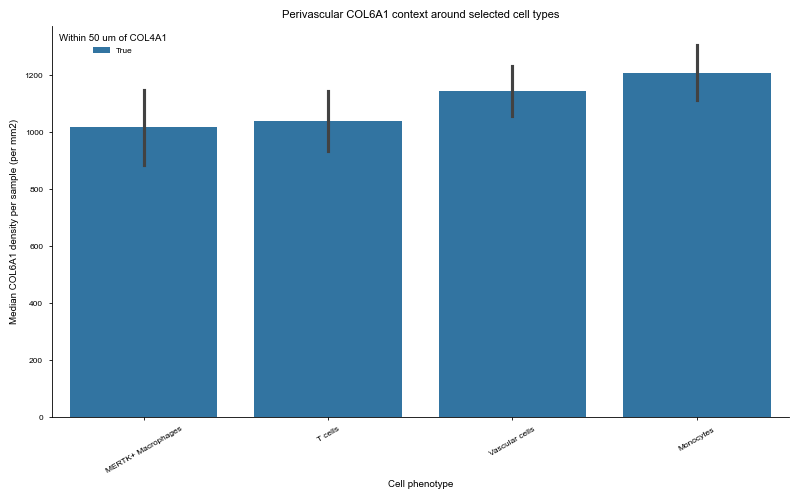

In [13]:
# ── Perivascular COL6 niche ─────────────────────────────────────────────────
# [reason] Cells near COL4A1 (basement membrane) experience different COL6A1
# density than cells in the parenchymal stroma — perivascular vs interstitial.
adata_perivascular = adata.copy()
adata_perivascular = cell_to_fiber_distance(
    adata_perivascular,
    fiber_df,
    links_df,
    fiber_type_key=FIBER_TYPE_KEY,
    fiber_type="COL4A1",
    phenotype_key=PHENOTYPE_KEY,
    phenotype=paper_cell_types,
)
adata_perivascular = fiber_density_near_cells(
    adata_perivascular,
    fiber_df,
    links_df,
    fiber_type_key=FIBER_TYPE_KEY,
    fiber_type="COL6A1",
    phenotype_key=PHENOTYPE_KEY,
    phenotype=paper_cell_types,
    normalize=True,
    density_radius=PROXIMITY_RADIUS_PX,
)

perivascular_df = adata_perivascular.obs[
    [IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "dist_to_COL4A1", "COL6A1_density", "COL6_dark_region"]
].copy()
perivascular_df["dist_to_COL4A1_um"] = perivascular_df["dist_to_COL4A1"] * PIXEL_SIZE_UM
perivascular_df["COL6A1_density_per_mm2"] = perivascular_df["COL6A1_density"] / (PIXEL_SIZE_UM ** 2) * 1e6
perivascular_df["near_COL4A1"] = perivascular_df["dist_to_COL4A1_um"].le(PROXIMITY_RADIUS_UM)
perivascular_df = perivascular_df.dropna(subset=["dist_to_COL4A1_um", "COL6A1_density_per_mm2"])
perivascular_df.to_csv(TABLES_DIR / "07_perivascular_col6_cell_context.csv", index=False)

perivascular_plot_types = ["MERTK+ Macrophages", "T cells", "Vascular cells", "Monocytes"]
perivascular_summary = sample_level_summary(
    perivascular_df[perivascular_df[PHENOTYPE_KEY].isin(perivascular_plot_types)],
    [IMAGE_KEY, GROUP_KEY, PHENOTYPE_KEY, "near_COL4A1"],
    "COL6A1_density_per_mm2",
    summary_name="median_COL6A1_density_per_mm2",
)
perivascular_summary.to_csv(TABLES_DIR / "07b_perivascular_col6_cell_context_by_sample.csv", index=False)
display(perivascular_summary.head())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=perivascular_summary,
    x=PHENOTYPE_KEY,
    y="median_COL6A1_density_per_mm2",
    hue="near_COL4A1",
    order=[x for x in perivascular_plot_types if x in paper_cell_types],
    errorbar="se",
    ax=ax,
)
ax.set_title("Perivascular COL6A1 context around selected cell types")
ax.set_xlabel("Cell phenotype")
ax.set_ylabel("Median COL6A1 density per sample (per mm2)")
ax.tick_params(axis="x", rotation=30)
ax.legend(title=f"Within {PROXIMITY_RADIUS_UM} um of COL4A1", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "06_perivascular_col6_density_by_cell_type.png")
plt.show()


**How to read this section.** This is the perivascular niche test: cells are stratified by whether their nearest linked COL4A1 fiber lies within the proximity radius, then local COL6A1 density is summarized per sample. Vascular cells are a useful positive-control phenotype; MERTK+ macrophages and T cells are the paper-guided immune phenotypes.


## 6. ECM organization with Moran's I

SpatioEv functions showcased: `morans_i_fibers` and `local_morans_i_fibers`.

Paper-guided questions:

- Is COL6A1, CHP, COL4A1, FN, or COL1A1bis spatially organized differently in RA versus OA?
- Are fiber morphology features such as area, length, eccentricity, or alignment spatially autocorrelated?

The current implementation constructs a dense kNN matrix, so this demonstration samples fibers for large images. This keeps the notebook safe while showcasing the function behavior.


,imageid,pathology,fiber_type,feature,morans_i,n_fibers_used,n_fibers_total
0,JRP112,RA,COL6A1,area,0.000211,2500,8053
1,JRP112,RA,COL6A1,major_axis_length,-0.003278,2500,8053
2,JRP112,RA,COL6A1,eccentricity,-0.003247,2500,8053
3,JRP112,RA,COL6A1,alignment_score,0.289748,2500,8053
4,JRP112,RA,CHP,area,-0.002517,2500,2727


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/07_fiber_morans_i_by_type_pathology.png


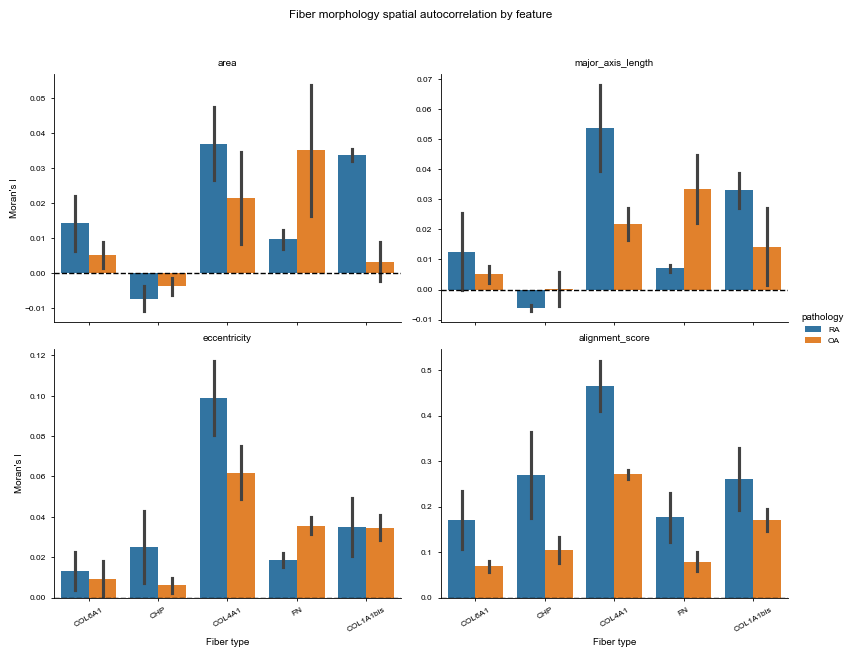

Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/07b_group_delta_fiber_morans_i_heatmap.png


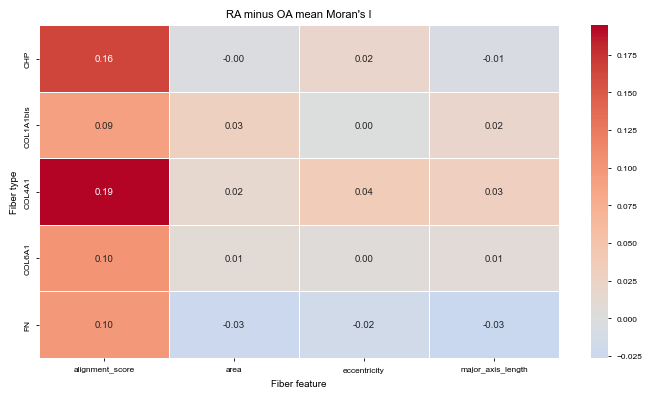

In [14]:
# ── ECM organisation: Moran's I on fiber morphology ──────────────────────────
# [reason] sv.tl.morans_i_fibers tests whether fiber shape/alignment is
# regionally concentrated — positive I = local ECM heterogeneity.
moran_rows = []
for image_id in sorted(fiber_df[IMAGE_KEY].dropna().unique()):
    fiber_img = fiber_df[fiber_df[IMAGE_KEY].eq(image_id)].copy()
    pathology = fiber_img[GROUP_KEY].dropna().iloc[0]
    for fiber_type in paper_fiber_types:
        sub = fiber_img[fiber_img[FIBER_TYPE_KEY].eq(fiber_type)].copy()
        if len(sub) < 20:
            continue
        sub_sample = sample_fibers(sub, max_n=MAX_FIBERS_FOR_MORAN)
        for feature in MORAN_FEATURES:
            if feature not in sub_sample.columns:
                continue
            try:
                stat = morans_i_fibers(
                    sub_sample,
                    feature=feature,
                    k=8,
                    fiber_type_key=FIBER_TYPE_KEY,
                    fiber_type=fiber_type,
                )
            except Exception as exc:
                warnings.warn(f"Moran failed {image_id} {fiber_type} {feature}: {exc}")
                stat = np.nan
            moran_rows.append({
                IMAGE_KEY: image_id,
                GROUP_KEY: pathology,
                "fiber_type": fiber_type,
                "feature": feature,
                "morans_i": stat,
                "n_fibers_used": len(sub_sample),
                "n_fibers_total": len(sub),
            })

moran_df = pd.DataFrame(moran_rows)
moran_df.to_csv(TABLES_DIR / "08_fiber_morans_i_by_sample_type_feature.csv", index=False)
display(moran_df.head())

if not moran_df.empty:
    g = sns.catplot(
        data=moran_df,
        kind="bar",
        x="fiber_type",
        y="morans_i",
        hue=GROUP_KEY,
        col="feature",
        col_wrap=2,
        errorbar="se",
        height=3.2,
        aspect=1.25,
        sharey=False,
    )
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)
    g.set_axis_labels("Fiber type", "Moran's I")
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle("Fiber morphology spatial autocorrelation by feature")
    savefig(g.fig, "07_fiber_morans_i_by_type_pathology.png")
    plt.show()

    moran_mean = (
        moran_df.groupby([GROUP_KEY, "fiber_type", "feature"], observed=True)["morans_i"]
        .mean()
        .reset_index()
    )
    # Use the actual group labels from the data (may differ from "RA"/"OA" strings)
    _groups = sorted(moran_mean[GROUP_KEY].dropna().unique())
    if len(_groups) == 2:
        _g1, _g2 = _groups  # e.g. ("OA", "RA") alphabetical
        _pivot = moran_mean.pivot_table(
            index=["fiber_type", "feature"], columns=GROUP_KEY, values="morans_i"
        ).reset_index()
        _pivot["delta"] = _pivot[_g2] - _pivot[_g1]
        _pivot.columns.name = None
        _pivot.rename(columns={"delta": f"{_g2}_minus_{_g1}"}, inplace=True)
        _pivot.to_csv(TABLES_DIR / "08b_fiber_morans_i_group_delta.csv", index=False)

        heat = _pivot.pivot(index="fiber_type", columns="feature", values=f"{_g2}_minus_{_g1}")
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.heatmap(heat, cmap="coolwarm", center=0, annot=True, fmt=".2f",
                    linewidths=0.5, ax=ax)
        ax.set_title(f"{_g2} minus {_g1} mean Moran's I")
        ax.set_xlabel("Fiber feature"); ax.set_ylabel("Fiber type")
        fig.tight_layout()
        savefig(fig, "07b_group_delta_fiber_morans_i_heatmap.png")
        plt.show()


**How to read this section.** Global Moran's I measures whether nearby fibers share similar morphology. Positive values indicate spatially organized ECM structure. Faceting by feature avoids mixing area, length, eccentricity, and alignment into one visual scale; the RA-minus-OA heatmap is a compact hypothesis-generating summary.


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/08_local_moran_col6_alignment_example.png


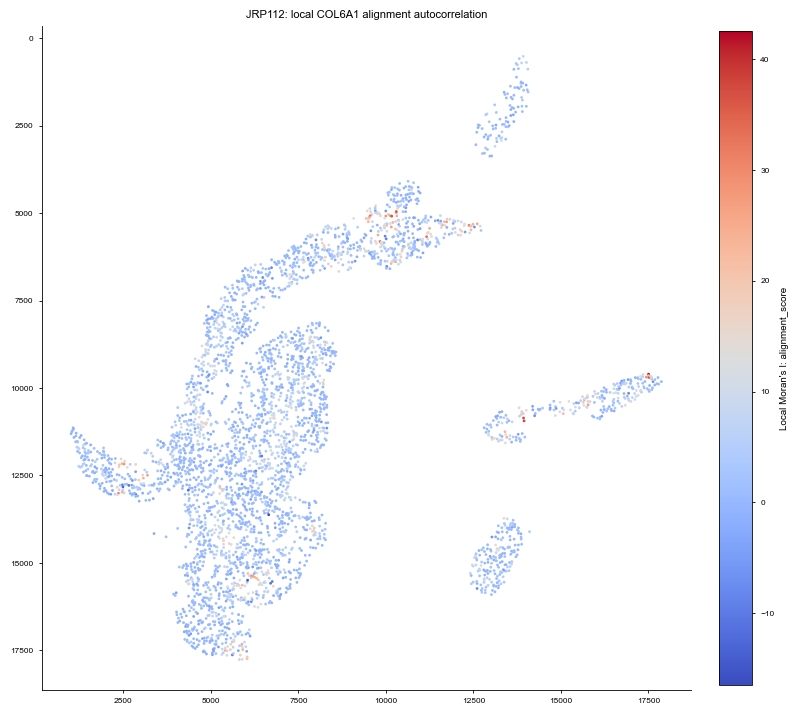

In [15]:
# Local Moran example: map COL6A1 alignment hotspots in one representative image.
LOCAL_MORAN_IMAGE = "JRP112"
LOCAL_MORAN_FIBER_TYPE = "COL6A1"
LOCAL_MORAN_FEATURE = "alignment_score"

local_fiber = fiber_df[
    fiber_df[IMAGE_KEY].eq(LOCAL_MORAN_IMAGE)
    & fiber_df[FIBER_TYPE_KEY].eq(LOCAL_MORAN_FIBER_TYPE)
].copy()
local_fiber = sample_fibers(local_fiber, max_n=MAX_FIBERS_FOR_LOCAL_PLOTS)
local_fiber = local_morans_i_fibers(
    local_fiber,
    feature=LOCAL_MORAN_FEATURE,
    k=8,
    fiber_type_key=FIBER_TYPE_KEY,
    fiber_type=LOCAL_MORAN_FIBER_TYPE,
)
local_col = f"local_moran_{LOCAL_MORAN_FEATURE}"
local_fiber.to_csv(TABLES_DIR / "09_local_moran_col6_alignment_example.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    local_fiber[X_KEY],
    local_fiber[Y_KEY],
    c=local_fiber[local_col],
    s=4,
    cmap="coolwarm",
    linewidth=0,
)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=f"Local Moran's I: {LOCAL_MORAN_FEATURE}")
ax.set_title(f"{LOCAL_MORAN_IMAGE}: local COL6A1 alignment autocorrelation")
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.grid(False)
sns.despine(ax=ax)
fig.tight_layout()
savefig(fig, "08_local_moran_col6_alignment_example.png")
plt.show()


## 7. Mapping cell niches onto fibers and cross Moran's I

SpatioEv functions showcased: `map_cells_to_fibers_kernel`, `cross_morans_i_ecm_cells`, `cross_morans_i_ecm_cells_permutation_test`, and `local_cross_morans_i_ecm_cells`.

Paper-guided questions:

- Are monocyte-rich neighborhoods spatially coupled to CHP or COL6A1 fiber morphology?
- Are MERTK+ macrophage or T-cell neighborhoods coupled to COL6A1 or COL4A1 fiber structure?
- Where are local hotspots of ECM-cell coupling?


,imageid,pathology,fiber_type,phenotype,fiber_feature,cross_morans_i,n_fibers_used
0,JRP112,RA,CHP,Monocytes,area,0.007971,2500
1,JRP112,RA,COL6A1,Monocytes,area,0.020485,2500
2,JRP112,RA,COL6A1,T cells,alignment_score,0.189847,2500
3,JRP112,RA,COL6A1,MERTK+ Macrophages,alignment_score,-0.047758,2500
4,JRP112,RA,COL4A1,Vascular cells,area,0.077077,1313


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/09_cross_morans_i_ecm_cell_coupling.png


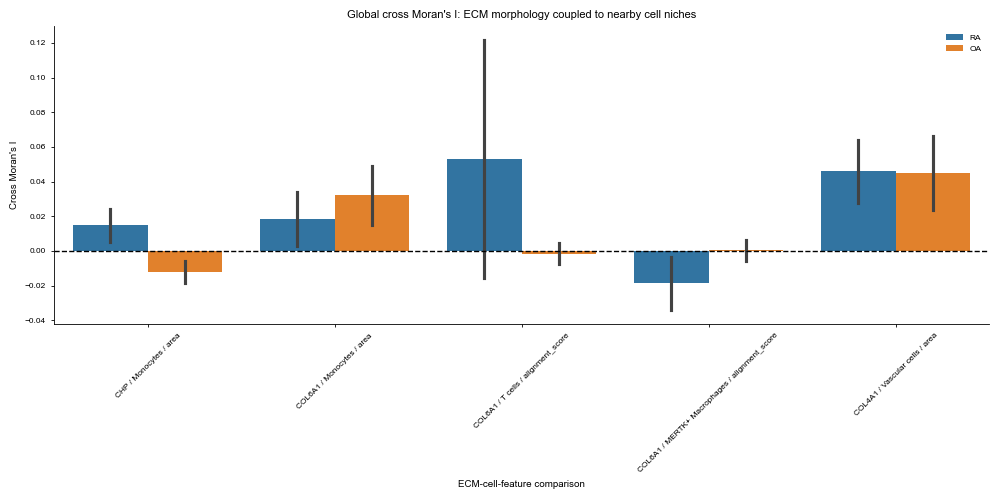

In [16]:
# ── Cross Moran's I: ECM-cell spatial coupling ───────────────────────────────
# [reason] sv.tl.cross_morans_i_ecm_cells asks whether a fiber morphology
# feature (e.g. CHP area) co-varies spatially with a nearby cell phenotype.
coupling_rows = []
coupling_specs = [
    ("CHP", "Monocytes", "area"),
    ("COL6A1", "Monocytes", "area"),
    ("COL6A1", "T cells", "alignment_score"),
    ("COL6A1", "MERTK+ Macrophages", "alignment_score"),
    ("COL4A1", "Vascular cells", "area"),
]
coupling_specs = [(f, p, feat) for f, p, feat in coupling_specs if f in paper_fiber_types and p in paper_cell_types]

for image_id in sorted(adata.obs[IMAGE_KEY].unique()):
    adata_img, fiber_img, links_img = subset_image_objects(image_id)
    pathology = adata_img.obs[GROUP_KEY].dropna().iloc[0]
    for fiber_type, phenotype, feature in coupling_specs:
        fibers_sub = fiber_img[fiber_img[FIBER_TYPE_KEY].eq(fiber_type)].copy()
        if len(fibers_sub) < 20 or feature not in fibers_sub.columns:
            continue
        fibers_sub = sample_fibers(fibers_sub, max_n=MAX_FIBERS_FOR_MORAN)
        links_sub = links_img[links_img["fiber_id"].isin(fibers_sub.index)].copy()
        if links_sub.empty:
            continue

        cell_feature = f"is_{phenotype.replace(' ', '_').replace('+', 'pos').replace('/', '_')}"
        try:
            stat = cross_morans_i_ecm_cells(
                adata_img,
                fibers_sub,
                links_sub,
                feature_fiber=feature,
                cell_feature=cell_feature,
                k=8,
            )
        except Exception as exc:
            warnings.warn(f"Cross Moran failed {image_id} {fiber_type} {phenotype} {feature}: {exc}")
            stat = np.nan

        coupling_rows.append({
            IMAGE_KEY: image_id,
            GROUP_KEY: pathology,
            "fiber_type": fiber_type,
            PHENOTYPE_KEY: phenotype,
            "fiber_feature": feature,
            "cross_morans_i": stat,
            "n_fibers_used": len(fibers_sub),
        })

coupling_df = pd.DataFrame(coupling_rows)
coupling_df.to_csv(TABLES_DIR / "10_cross_morans_i_ecm_cell_coupling.csv", index=False)
display(coupling_df.head())

fig, ax = plt.subplots(figsize=(10, 5))
if not coupling_df.empty:
    coupling_df["comparison"] = coupling_df["fiber_type"] + " / " + coupling_df[PHENOTYPE_KEY] + " / " + coupling_df["fiber_feature"]
    sns.barplot(
        data=coupling_df,
        x="comparison",
        y="cross_morans_i",
        hue=GROUP_KEY,
        errorbar="se",
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Global cross Moran's I: ECM morphology coupled to nearby cell niches")
    ax.set_xlabel("ECM-cell-feature comparison")
    ax.set_ylabel("Cross Moran's I")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    fig.tight_layout()
    savefig(fig, "09_cross_morans_i_ecm_cell_coupling.png")
    plt.show()
else:
    print("No cross Moran results were produced.")


**How to read this section.** Cross Moran's I asks whether an ECM feature is spatially coupled to a nearby cell niche. Positive values mean high ECM feature values tend to occur near high local cell signal in neighboring fiber space; negative values suggest separation. Treat this as a focused sample-level effect-size screen unless the optional permutation block is enabled.


Saved: /Users/shihongwu/SpatioEv/notebooks/results/ra_oa_ecm_cell/spatioev_module_paper_applications/figures/10_local_cross_moran_chp_monocyte_example.png


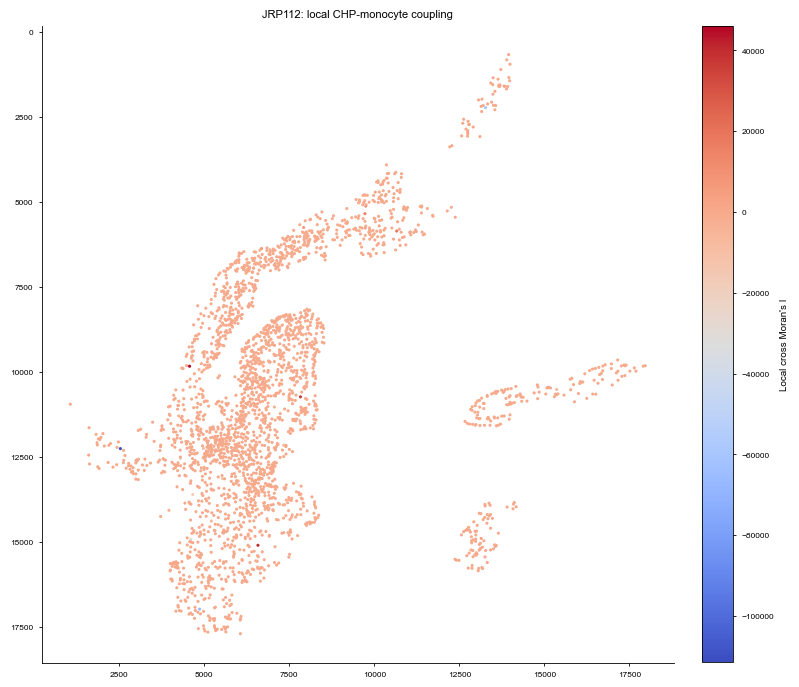

In [17]:
# Local cross Moran example: CHP area coupled to monocyte neighborhoods in one image.
LOCAL_CROSS_IMAGE = "JRP112"
LOCAL_CROSS_FIBER_TYPE = "CHP"
LOCAL_CROSS_CELL = "Monocytes"
LOCAL_CROSS_FEATURE = "area"

adata_img, fiber_img, links_img = subset_image_objects(LOCAL_CROSS_IMAGE)
fiber_local = fiber_img[fiber_img[FIBER_TYPE_KEY].eq(LOCAL_CROSS_FIBER_TYPE)].copy()
fiber_local = sample_fibers(fiber_local, max_n=MAX_FIBERS_FOR_LOCAL_PLOTS)
links_local = links_img[links_img["fiber_id"].isin(fiber_local.index)].copy()

if not links_local.empty and LOCAL_CROSS_CELL in paper_cell_types:
    fiber_local = map_cells_to_fibers_kernel(
        adata_img,
        fiber_local,
        links_local,
        phenotype_key=PHENOTYPE_KEY,
        phenotype=LOCAL_CROSS_CELL,
        bandwidth=PROXIMITY_RADIUS_PX,
    )
    cell_feature = f"{LOCAL_CROSS_CELL}_kernel_density"
    fiber_local = local_cross_morans_i_ecm_cells(
        fiber_local,
        feature_fiber=LOCAL_CROSS_FEATURE,
        feature_cell=cell_feature,
        k=8,
        fiber_type_key=FIBER_TYPE_KEY,
        fiber_type=LOCAL_CROSS_FIBER_TYPE,
    )
    local_cross_col = f"local_cross_moran_{LOCAL_CROSS_FEATURE}_{cell_feature}"
    fiber_local.to_csv(TABLES_DIR / "11_local_cross_moran_chp_monocyte_example.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 8))
    sc = ax.scatter(
        fiber_local[X_KEY],
        fiber_local[Y_KEY],
        c=fiber_local[local_cross_col],
        s=5,
        cmap="coolwarm",
        linewidth=0,
    )
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Local cross Moran's I")
    ax.set_title(f"{LOCAL_CROSS_IMAGE}: local CHP-monocyte coupling")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.grid(False)
    sns.despine(ax=ax)
    fig.tight_layout()
    savefig(fig, "10_local_cross_moran_chp_monocyte_example.png")
    plt.show()
else:
    print("Local cross Moran example skipped because no linked fibers were available.")


In [18]:
if RUN_CROSS_MORAN_PERMUTATIONS and coupling_specs:
    perm_rows = []
    for image_id in sorted(adata.obs[IMAGE_KEY].unique()):
        adata_img, fiber_img, links_img = subset_image_objects(image_id)
        pathology = adata_img.obs[GROUP_KEY].dropna().iloc[0]
        for fiber_type, phenotype, feature in coupling_specs[:3]:
            fibers_sub = fiber_img[fiber_img[FIBER_TYPE_KEY].eq(fiber_type)].copy()
            if len(fibers_sub) < 20:
                continue
            fibers_sub = sample_fibers(fibers_sub, max_n=MAX_FIBERS_FOR_MORAN)
            links_sub = links_img[links_img["fiber_id"].isin(fibers_sub.index)].copy()
            cell_feature = f"is_{phenotype.replace(' ', '_').replace('+', 'pos').replace('/', '_')}"
            try:
                res = cross_morans_i_ecm_cells_permutation_test(
                    adata_img,
                    fibers_sub,
                    links_sub,
                    feature_fiber=feature,
                    cell_feature=cell_feature,
                    k=8,
                    n_sim=N_CROSS_MORAN_SIM,
                    image_key=IMAGE_KEY,
                    random_state=RANDOM_STATE,
                )
            except Exception as exc:
                warnings.warn(f"Cross Moran permutation failed {image_id} {fiber_type} {phenotype}: {exc}")
                continue
            res.update({
                IMAGE_KEY: image_id,
                GROUP_KEY: pathology,
                "fiber_type": fiber_type,
                PHENOTYPE_KEY: phenotype,
                "fiber_feature": feature,
            })
            perm_rows.append(res)
    cross_moran_perm_df = pd.DataFrame(perm_rows)
    cross_moran_perm_df.to_csv(TABLES_DIR / "12_cross_morans_i_permutation_tests.csv", index=False)
    display(cross_moran_perm_df.head())
else:
    print("Cross Moran permutation tests skipped. Set RUN_CROSS_MORAN_PERMUTATIONS=True for manuscript runs.")


Cross Moran permutation tests skipped. Set RUN_CROSS_MORAN_PERMUTATIONS=True for manuscript runs.


## 8. ECM-cell neighborhood profiling

SpatioEv functions showcased: `build_ecm_cell_neighborhood_features`,
`cluster_ecm_cell_neighborhoods`, `score_col6_dark_neighborhoods`.

**Paper-guided questions:**
- Do immune cells form spatially distinct ECM-cell neighborhood types
  that separate COL6A1-rich from CHP-rich or matrix-poor zones?
- Which neighborhood clusters correspond to COL6 dark-zone cores
  vs vascular-proximal vs open-matrix regions?
- Do RA and OA samples differ in their neighborhood-type composition?

`build_ecm_cell_neighborhood_features` computes, for each cell, the local
ECM density (COL6A1, CHP) and neighbour cell phenotype composition within 50 µm.
`cluster_ecm_cell_neighborhoods` groups these feature vectors into K discrete
neighbourhood types using K-means. `score_col6_dark_neighborhoods` then labels
clusters with low COL6A1 AND CHP density as COL6-dark.


Neighborhood features: (662388, 62)


,cell_id,imageid,pathology,phenotype,X_centroid,Y_centroid,cell_count_B_cells,cell_density_B_cells,cell_count_CD4_T_cells,cell_density_CD4_T_cells,cell_count_CD8_T_cells,cell_density_CD8_T_cells,cell_count_Dendritic_cells,cell_density_Dendritic_cells,cell_count_MERTK_Macrophages,cell_density_MERTK_Macrophages,cell_count_Macrophages,cell_density_Macrophages,cell_count_Monocytes,cell_density_Monocytes,cell_count_Myeloid_cells,cell_density_Myeloid_cells,cell_count_Neutrophils,cell_density_Neutrophils,cell_count_Non_immune_cells,cell_density_Non_immune_cells,cell_count_Other_Immune_cells,cell_density_Other_Immune_cells,cell_count_Plasma_cells,cell_density_Plasma_cells,cell_count_T_cells,cell_density_T_cells,cell_count_Vascular_cells,cell_density_Vascular_cells,neighbor_cell_count,neighbor_cell_density,cell_fraction_B_cells,cell_fraction_CD4_T_cells,cell_fraction_CD8_T_cells,cell_fraction_Dendritic_cells,cell_fraction_MERTK_Macrophages,cell_fraction_Macrophages,cell_fraction_Monocytes,cell_fraction_Myeloid_cells,cell_fraction_Neutrophils,cell_fraction_Non_immune_cells,cell_fraction_Other_Immune_cells,cell_fraction_Plasma_cells,cell_fraction_T_cells,cell_fraction_Vascular_cells,fiber_count_COL6A1,fiber_density_COL6A1,fiber_weight_COL6A1,nearest_distance_COL6A1,fiber_count_CHP,fiber_density_CHP,fiber_weight_CHP,nearest_distance_CHP,neighbor_fiber_count,fiber_fraction_COL6A1,fiber_fraction_CHP,COL6A1_CHP_count_ratio
JRP112_0,JRP112_0,JRP112,RA,Other Immune cells,13100.311872,185.782437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.00000,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0
JRP112_1,JRP112_1,JRP112,RA,Non-immune cells,14070.780340,467.928398,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,254.647909,2.0,254.647909,0.0,0.0,2.0,254.647909,0.0,0.0,6.0,763.943727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,0.333333,0.0,2.0,254.647909,0.30502,137.233246,0.0,0.0,0.0,NaN,2.0,1.0,0.0,3.0
JRP112_2,JRP112_2,JRP112,RA,Other Immune cells,14004.151738,487.922460,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,381.971863,2.0,254.647909,0.0,0.0,1.0,127.323954,0.0,0.0,6.0,763.943727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.333333,0.0,0.166667,0.0,3.0,381.971863,0.70750,83.475223,0.0,0.0,0.0,NaN,3.0,1.0,0.0,4.0


Neighborhood clusters: 8 types

Neighborhood cluster summary (sorted by COL6-dark score):


,ecm_cell_neighborhood,n_cells,median_col6_density,median_chp_density,median_cell_density,low_col6,low_chp,inside_tissue_like,col6_dark_candidate
4,4,193340,636.619772,509.295818,4965.634224,True,True,True,True
0,0,9881,1273.239545,763.943727,9676.620540,False,False,True,False
1,1,131344,1273.239545,1273.239545,4710.986316,False,False,False,False
2,2,80268,1400.563499,636.619772,12350.423584,False,True,True,False
3,3,151012,1527.887454,636.619772,6366.197724,False,True,True,False
5,5,24490,1400.563499,1018.591636,10695.212176,False,False,True,False
6,6,16424,891.267681,1145.915590,20626.480625,True,False,True,False
7,7,55629,636.619772,763.943727,10949.860085,True,False,True,False


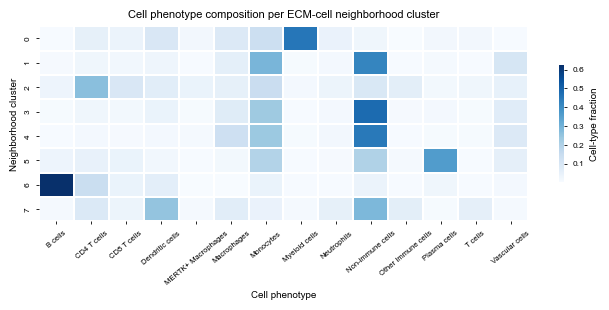

In [19]:
# ── ECM-cell neighborhood profiling ─────────────────────────────────────────
# [reason] This is the most structurally novel sv.tl demonstration:
# building unsupervised ECM-cell neighborhood types that integrate both the
# matrix composition and local immune context around each cell.
# No equivalent workflow exists in standard scanpy/squidpy pipelines.

from spatioev.tl import (
    build_ecm_cell_neighborhood_features,
    cluster_ecm_cell_neighborhoods,
    score_col6_dark_neighborhoods,
)

N_NEIGHBORHOOD_CLUSTERS = 8
_RADIUS_PX = PROXIMITY_RADIUS_PX  # 50 µm

# Step 1: build per-cell ECM-cell neighborhood feature vectors
neighborhood_df = build_ecm_cell_neighborhood_features(
    adata,
    fiber_df,
    links_df,
    radius=_RADIUS_PX,
    phenotype_key=PHENOTYPE_KEY,
    image_key=IMAGE_KEY,
    group_key=GROUP_KEY,
    x_key=X_KEY,
    y_key=Y_KEY,
    fiber_type_key=FIBER_TYPE_KEY,
    fiber_types=["COL6A1", "CHP"],
    pixel_size_um=PIXEL_SIZE_UM,
)
print(f"Neighborhood features: {neighborhood_df.shape}")
display(neighborhood_df.head(3))

# Step 2: cluster into N discrete neighborhood types
# cluster_ecm_cell_neighborhoods returns (clustered_df, model, scaler, feature_cols)
# The label column is already written into the returned DataFrame.
neighborhood_df, _km_model, _km_scaler, _km_features = cluster_ecm_cell_neighborhoods(
    neighborhood_df, n_clusters=N_NEIGHBORHOOD_CLUSTERS, random_state=RANDOM_STATE
)
print(f"Neighborhood clusters: {neighborhood_df['ecm_cell_neighborhood'].nunique()} types")

# Step 3: score which clusters are COL6-dark
neighborhood_df, dark_scores = score_col6_dark_neighborhoods(
    neighborhood_df,
    label_key="ecm_cell_neighborhood",
    col6_density_col="fiber_density_COL6A1",
    chp_density_col="fiber_density_CHP",
)
print("\nNeighborhood cluster summary (sorted by COL6-dark score):")
# dark_scores is the cluster-level summary table (not per-cell)
# sort by col6_dark_candidate to see which clusters are COL6-dark
display(dark_scores.sort_values("col6_dark_candidate", ascending=False))

# Merge neighborhood labels back to adata.obs for downstream use
adata.obs["ecm_cell_neighborhood"] = neighborhood_df["ecm_cell_neighborhood"].values
# The dark-zone label column is named by output_key (default: "COL6_dark_neighborhood")
adata.obs["COL6_dark_neighborhood"] = neighborhood_df["COL6_dark_neighborhood"].values

neighborhood_df.to_csv(TABLES_DIR / "11_ecm_cell_neighborhood_profiles.csv", index=False)
dark_scores.to_csv(TABLES_DIR / "12_ecm_neighborhood_dark_scores.csv", index=False)

# Plot: phenotype composition per neighborhood cluster
pheno_by_nhood = (
    neighborhood_df.groupby(["ecm_cell_neighborhood", PHENOTYPE_KEY], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
pheno_by_nhood["frac"] = pheno_by_nhood["n"] / pheno_by_nhood.groupby("ecm_cell_neighborhood")["n"].transform("sum")

fig, ax = plt.subplots(figsize=(6.5, 3.0))
pivot = pheno_by_nhood.pivot(index="ecm_cell_neighborhood", columns=PHENOTYPE_KEY, values="frac").fillna(0)
import seaborn as sns
sns.heatmap(pivot, cmap="Blues", linewidths=0.2, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Cell-type fraction"})
ax.set_title("Cell phenotype composition per ECM-cell neighborhood cluster", fontsize=8)
ax.set_ylabel("Neighborhood cluster", fontsize=7)
ax.set_xlabel("Cell phenotype", fontsize=7)
ax.tick_params(axis="x", rotation=40, labelsize=5.5)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout(pad=0.5)
plt.savefig(FIGURES_DIR / "fig_ecm_neighborhood_phenotype_heatmap.pdf")
plt.show()


**How to read this section.** Each row in the neighbourhood heatmap is one K-means cluster — a distinct ECM-cell context type. Clusters where immune cells (T cells, macrophages, monocytes) are concentrated alongside low COL6A1/CHP density correspond to COL6 dark zones. Clusters with high vascular cell fractions and high COL4A1 density correspond to perivascular niches. This unsupervised decomposition is replicable across any cohort where ECM fiber segmentation and cell phenotyping are available.


## 9. Spatial enrichment score

SpatioEv function showcased: `spatial_enrichment_score`.

**Paper-guided question:** Which immune cell phenotypes are enriched in
COL6A1-high vs COL6A1-low spatial regions? Does this enrichment differ
between RA and OA?

`spatial_enrichment_score` links a continuous spatial feature (e.g. local
COL6A1 density) to cell phenotype identity by computing the mean feature
value experienced by each phenotype, then compares across groups.


Spatial enrichment scores (feature: fiber_density_COL6A1):


/Users/shihongwu/SpatioEv/spatioev/tl/ecm.py:1869: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(phenotype_key)[feature]


,phenotype,mean_feature
0,CD8 T cells,1270.048947
1,CD4 T cells,1254.788538
2,Monocytes,1135.342873
3,MERTK+ Macrophages,1114.661117
4,Dendritic cells,1102.638464
5,Vascular cells,1093.358342
6,Neutrophils,1037.588249
7,T cells,1026.097081
8,B cells,982.676869
9,Macrophages,975.019488


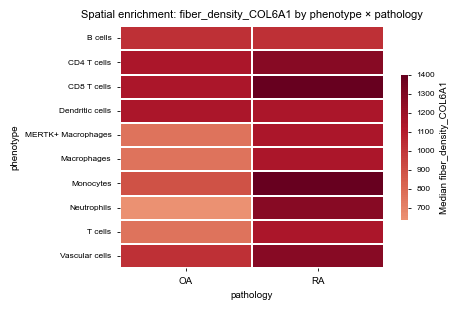

In [20]:
# ── Spatial enrichment score ─────────────────────────────────────────────────
# [reason] sv.tl.spatial_enrichment_score is a fast, interpretable test for
# whether specific cell types accumulate in ECM-rich or ECM-poor regions.
# Unlike cross Moran's I (section 7), it does not require a linked fiber table
# and can be applied to any per-cell spatial feature already in adata.obs.

from spatioev.tl import spatial_enrichment_score

# Use local COL6A1 fiber density per cell (computed in section 3)
# or fall back to the dark-zone binary label
if "fiber_density_COL6A1" in adata.obs.columns:
    enrichment_feature = "fiber_density_COL6A1"
elif "COL6A1_density" in adata.obs.columns:
    enrichment_feature = "COL6A1_density"
else:
    # Build it now from neighborhood features
    if "ecm_cell_neighborhood" in neighborhood_df.columns:
        adata.obs["fiber_density_COL6A1"] = neighborhood_df["fiber_density_COL6A1"].values
        enrichment_feature = "fiber_density_COL6A1"
    else:
        enrichment_feature = None

if enrichment_feature is not None:
    # spatial_enrichment_score returns a Series: phenotype → mean feature value
    enrichment_scores = spatial_enrichment_score(
        adata.obs,
        feature=enrichment_feature,
        phenotype_key=PHENOTYPE_KEY,
        phenotype=PAPER_CELL_TYPES,
    )
    enrichment_df = enrichment_scores.rename("mean_feature").reset_index()
    enrichment_df.columns = [PHENOTYPE_KEY, "mean_feature"]
    print(f"Spatial enrichment scores (feature: {enrichment_feature}):")
    display(enrichment_df.sort_values("mean_feature", ascending=False))
    enrichment_df.to_csv(TABLES_DIR / "13_spatial_enrichment_col6a1.csv", index=False)

    # Compare RA vs OA enrichment for each phenotype
    enrich_by_group = (
        adata.obs[adata.obs[PHENOTYPE_KEY].isin(PAPER_CELL_TYPES)]
        .groupby([GROUP_KEY, PHENOTYPE_KEY], observed=True)[enrichment_feature]
        .median()
        .unstack(GROUP_KEY)
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(4.5, 3.0))
    sns.heatmap(enrich_by_group, cmap="RdBu_r", center=0, ax=ax, linewidths=0.2,
                cbar_kws={"shrink": 0.6, "label": f"Median {enrichment_feature}"})
    ax.set_title(f"Spatial enrichment: {enrichment_feature} by phenotype × pathology", fontsize=8)
    ax.tick_params(axis="y", labelsize=6)
    ax.tick_params(axis="x", labelsize=7)
    plt.tight_layout(pad=0.5)
    plt.savefig(FIGURES_DIR / "fig_spatial_enrichment_col6a1.pdf")
    plt.show()
else:
    print("fiber_density_COL6A1 not found — run section 3 (fiber_density_near_cells) first.")


**How to read this section.** Each row in the heatmap is a cell phenotype. Red = that phenotype tends to sit in COL6A1-rich tissue; blue = it tends to sit in COL6A1-poor tissue. If monocytes are consistently blue (COL6A1-poor) while T cells are red (COL6A1-rich), it supports the interpretation that monocytes actively degrade the COL6A1 matrix around them while lymphocytes preferentially occupy intact COL6A1 networks.


## 8. Function-to-biology map

This notebook demonstrates the following `spatioev.tl.ecm` applications:

| Paper-guided biology | `sv.tl` function(s) | Output |
|---|---|---|
| COL6 dark-zone immune confinement | `cell_to_fiber_distance`, `fiber_density_near_cells` | distances and local ECM density experienced by each phenotype |
| Cell-fiber attraction or exclusion across spatial scale | `cross_ripleys_k`, `cross_ripleys_k_permutation_envelope` | scale-dependent association curves and optional null envelopes |
| Perivascular COL6 niche | `cell_to_fiber_distance`, `fiber_density_near_cells` | COL6A1 density around cells near COL4A1-positive vasculature |
| ECM organization | `morans_i_fibers`, `local_morans_i_fibers` | global and local spatial autocorrelation of fiber morphology |
| Monocyte/degradation-associated ECM-cell coupling | `map_cells_to_fibers_kernel`, `cross_morans_i_ecm_cells`, `local_cross_morans_i_ecm_cells` | global statistics and local hotspot maps |

For the manuscript supplement, the recommended high-confidence figures are:

1. COL6 dark-region cell density per area.
2. Cell-to-fiber distance by phenotype and fiber type.
3. Cross Ripley's K curves for COL6A1/CHP/COL4A1 paper-guided pairs.
4. Moran's I fiber organization summary.
5. Cross Moran or local cross Moran example for monocyte-CHP coupling.

| ECM-cell neighbourhood profiling | `build_ecm_cell_neighborhood_features`, `cluster_ecm_cell_neighborhoods`, `score_col6_dark_neighborhoods` | per-cell neighbourhood clusters and COL6-dark labels |
| Cell enrichment in ECM regions | `spatial_enrichment_score` | per-phenotype mean feature scores across RA/OA |
